# Brazilian E-Commerce Analytics

This notebook explores the Olist marketplace data, computes core business metrics, builds a monthly demand forecast for June-August 2018, and prepares an LLM-ready recommendation context.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'src':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import (
    build_analysis_context,
    forecast_demand,
    generate_recommendations,
    get_business_overview,
    prepare_monthly_demand,
)
from src.data_loader import load_all_data
from src.holdout_config import FORECAST_HORIZON, TRAIN_END_DATE

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

/Users/karimabilgaziyev/Bubstal_Technical_Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load and Inspect Data

In [2]:
data = load_all_data()
table_summary = pd.DataFrame(
    [
        {
            'table': name,
            'rows': len(df),
            'columns': df.shape[1],
            'missing_cells': int(df.isna().sum().sum()),
        }
        for name, df in data.items()
    ]
).sort_values('rows', ascending=False)
table_summary

,table,rows,columns,missing_cells
7,geolocation,1000163,5,0
1,order_items,112650,7,0
6,payments,103886,5,0
0,orders,99441,8,4908
4,customers,99441,5,0
5,reviews,99224,7,145903
2,products,32951,9,2448
3,sellers,3095,4,0
8,category_translation,71,2,0


In [3]:
orders = data['orders'].copy()
orders['order_purchase_timestamp'].agg(['min', 'max'])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[ns]

## Business Overview

In [4]:
overview = get_business_overview()
overview_cards = pd.DataFrame(
    [
        {'metric': 'Total revenue', 'value': overview['total_revenue']},
        {'metric': 'Total orders', 'value': overview['total_orders']},
        {'metric': 'Average order value', 'value': overview['avg_order_value']},
    ]
)
overview_cards

,metric,value
0,Total revenue,"16,008,872.12"
1,Total orders,"99,441.00"
2,Average order value,160.99


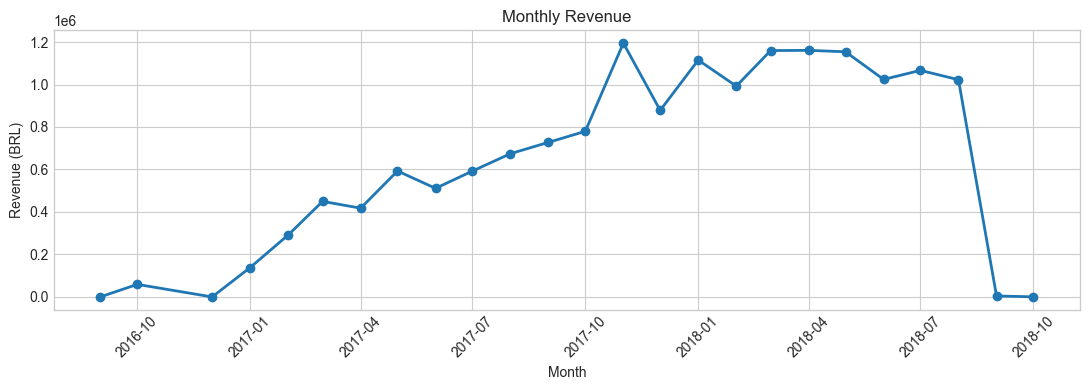

In [5]:
revenue_by_month = overview['revenue_by_month']
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(revenue_by_month['month'], revenue_by_month['revenue'], marker='o', linewidth=2)
ax.set_title('Monthly Revenue')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Product and Customer Mix

In [6]:
items = data['order_items']
products = data['products'][['product_id', 'product_category_name']]
translation = data['category_translation']

category_sales = items.merge(products, on='product_id', how='left').merge(translation, on='product_category_name', how='left')
category_sales['category'] = category_sales['product_category_name_english'].fillna(category_sales['product_category_name']).fillna('unknown')
category_sales['item_revenue'] = category_sales['price'].fillna(0) + category_sales['freight_value'].fillna(0)

top_categories = (
    category_sales.groupby('category', as_index=False)
    .agg(item_revenue=('item_revenue', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('item_revenue', ascending=False)
    .head(10)
)
top_categories

,category,item_revenue,orders
43,health_beauty,"1,441,248.07",8836
73,watches_gifts,"1,305,541.61",5624
7,bed_bath_table,"1,241,681.72",9417
67,sports_leisure,"1,156,656.48",7720
15,computers_accessories,"1,059,272.40",6689
39,furniture_decor,"902,511.79",6449
49,housewares,"778,397.77",5884
20,cool_stuff,"719,329.95",3632
5,auto,"685,384.32",3897
42,garden_tools,"584,219.21",3518


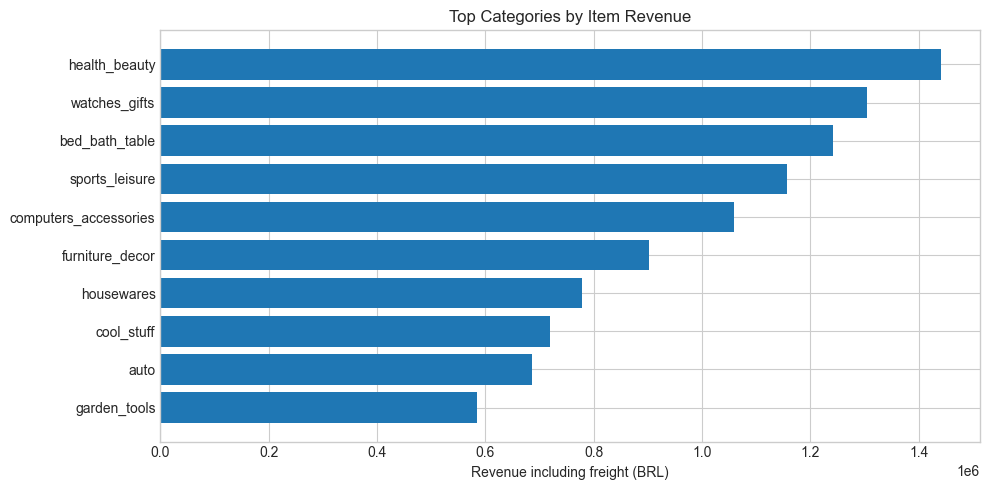

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_categories = top_categories.sort_values('item_revenue')
ax.barh(plot_categories['category'], plot_categories['item_revenue'])
ax.set_title('Top Categories by Item Revenue')
ax.set_xlabel('Revenue including freight (BRL)')
plt.tight_layout()

In [8]:
customer_orders = data['orders'].merge(data['customers'][['customer_id', 'customer_state']], on='customer_id', how='left')
state_orders = (
    customer_orders.groupby('customer_state', as_index=False)['order_id']
    .nunique()
    .rename(columns={'order_id': 'orders'})
    .sort_values('orders', ascending=False)
    .head(10)
)
state_orders

,customer_state,orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


## Demand Forecast

In [9]:
monthly_demand = prepare_monthly_demand()
train = monthly_demand[monthly_demand['month'] <= TRAIN_END_DATE.to_period('M').to_timestamp()]
holdout = monthly_demand[monthly_demand['month'] > TRAIN_END_DATE.to_period('M').to_timestamp()].head(FORECAST_HORIZON)
forecast_result = forecast_demand(train, horizon=FORECAST_HORIZON)
forecast_df = pd.DataFrame(forecast_result['predictions'])
forecast_df['month'] = pd.to_datetime(forecast_df['month'])
forecast_df

,month,predicted_order_count
0,2018-06-01,5456
1,2018-07-01,5956
2,2018-08-01,6218


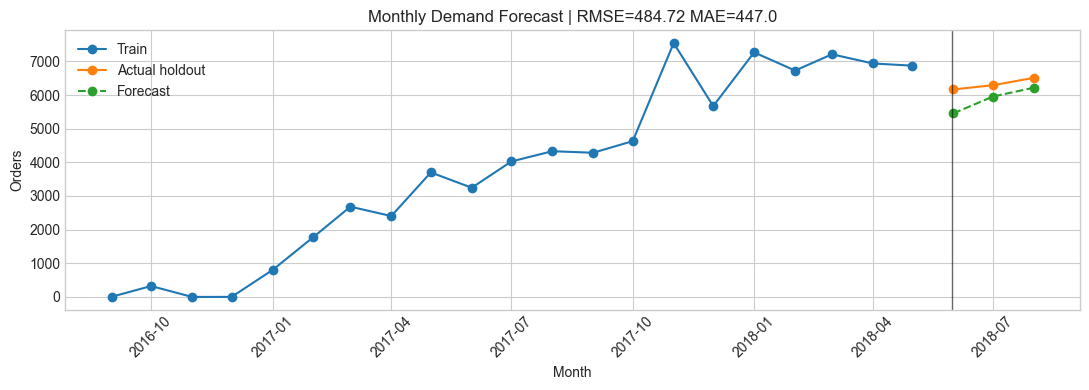

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train['month'], train['order_count'], marker='o', label='Train')
ax.plot(holdout['month'], holdout['order_count'], marker='o', label='Actual holdout')
ax.plot(forecast_df['month'], forecast_df['predicted_order_count'], marker='o', linestyle='--', label='Forecast')
ax.axvline(TRAIN_END_DATE, color='black', linewidth=1, alpha=0.6)
ax.set_title(f"Monthly Demand Forecast | RMSE={forecast_result['rmse']} MAE={forecast_result['mae']}")
ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

The baseline model combines a seasonal naive signal with recent trend and trailing average. It is deliberately simple and explainable, which is appropriate for a short assessment and gives leadership a transparent starting point.

## Satisfaction and Delivery

In [11]:
reviews = data['reviews']
review_summary = pd.DataFrame(
    [
        {'metric': 'Review count', 'value': reviews['review_id'].nunique()},
        {'metric': 'Average review score', 'value': reviews['review_score'].mean()},
        {'metric': 'Share scores 1-2', 'value': (reviews['review_score'] <= 2).mean()},
    ]
)
review_summary

,metric,value
0,Review count,"98,410.00"
1,Average review score,4.09
2,Share scores 1-2,0.15


In [12]:
delivered = orders.dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date']).copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
pd.DataFrame(
    [
        {'metric': 'Delivered orders', 'value': delivered['order_id'].nunique()},
        {'metric': 'Average delivery days', 'value': delivered['delivery_days'].mean()},
        {'metric': 'Late delivery share', 'value': delivered['is_late'].mean()},
    ]
)

,metric,value
0,Delivered orders,"96,476.00"
1,Average delivery days,12.56
2,Late delivery share,0.08


## LLM Recommendation Context

In [13]:
context = build_analysis_context()
print(context)

Brazilian e-commerce marketplace analysis context

Business overview:
- Total orders: 99,441
- Total revenue: BRL 16,008,872.12
- Average order value: BRL 160.99
- Date range: 2016-09-01 to 2018-10-01
- Forecast holdout period: 2018-06-01 to 2018-08-31

Recent complete monthly revenue through the holdout period:
- 2018-06: BRL 1,023,880.50
- 2018-07: BRL 1,066,540.75
- 2018-08: BRL 1,022,425.32

Demand forecast for the next quarter:
- 2018-06: 5,456 orders
- 2018-07: 5,956 orders
- 2018-08: 6,218 orders
- Holdout RMSE: 484.72; MAE: 447.0

Top revenue categories:
- health_beauty: BRL 1,441,248.07 across 8,836 orders
- watches_gifts: BRL 1,305,541.61 across 5,624 orders
- bed_bath_table: BRL 1,241,681.72 across 9,417 orders
- sports_leisure: BRL 1,156,656.48 across 7,720 orders
- computers_accessories: BRL 1,059,272.40 across 6,689 orders

Payment mix by value:
- credit_card: BRL 12,542,084.19 across 76,505 orders
- boleto: BRL 2,869,361.27 across 19,784 orders
- voucher: BRL 379,436.87 

In [14]:
recommendation_result = generate_recommendations()
pd.DataFrame(recommendation_result['recommendations'])

,action,rationale,priority
0,Plan seller capacity and inventory against the...,The forecast points to expected order volume o...,high
1,Prioritize the highest-revenue categories for ...,The leading categories are health_beauty: BRL ...,high
2,Reduce late deliveries and shorten fulfillment...,Delivery performance shows Delivered orders: 9...,high
3,Use payment mix insights to tune checkout and ...,Payment value is concentrated in credit_card: ...,medium
4,Focus regional operations on the largest custo...,"The largest customer states are SP: 41,746 ord...",medium
